In [3]:
%pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached tensorflow_io_gcs_filesystem-0.31.0-cp310-cp310-win_amd64.whl.metadata (14 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/375.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/375.7 MB 4.8 MB/s eta 0:01:19
   ---------------------------------------- 1.8/375.7 MB 5.0 MB/s eta 0:01:15
   ---------------------------------------- 3.1/375.7 MB 5.9 MB/s eta 0:01:03
   ---------------------------------------- 4

# Simple MLP neural network without movie overview embeddings (user + movie input, rating output)
 

In [28]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf

In [2]:
cols = [
    "UserID",
    "MovieID",
    "Rating",
    "Timestamp",
    "Name",
    "Action",
    "Adventure",
    "Animation",
    "Children's",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
    "adult",
    "original_language",
    "embedding",
    "popularity",
    "vote_average",
    "vote_count",
]

In [29]:
df = pd.read_parquet("../datasets/full_train_dataset_with_embeddings.parquet")

# 2. Define feature columns
genre_cols = [
    "Action",
    "Adventure",
    "Animation",
    "Children's",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
    "adult",
]
numeric_cols = ["popularity", "vote_average", "vote_count"]



In [30]:
user_vecs = df["UserID"].to_numpy(dtype=np.float32).reshape(-1, 1)
item_vecs = df[genre_cols + numeric_cols].to_numpy(dtype=np.float32)
ratings = df["Rating"].to_numpy(dtype=np.float32)

In [31]:
u_train, u_test, i_train, i_test, y_train, y_test = train_test_split(
    user_vecs, item_vecs, ratings, test_size=0.2, random_state=42
)

In [47]:
user_dim = u_train.shape[1]  # =1
item_dim = i_train.shape[1]  # = len(genre_cols) + len(numeric_cols)
hidden = 128

inp_u = tf.keras.Input(shape=(user_dim,), name="user_input")
inp_i = tf.keras.Input(shape=(item_dim,), name="item_input")

# 2) Concatenate
x = tf.keras.layers.Concatenate()([inp_u, inp_i])

# 3) A deeper MLP stack
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Dense(64, activation="relu")(x)
# you can add another Dropout/BatchNorm here if you like

x = tf.keras.layers.Dense(32, activation="relu")(x)

# 4) Final output
out = tf.keras.layers.Dense(1, name="rating")(x)

model = tf.keras.Model([inp_u, inp_i], out)



In [48]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

In [49]:
history = model.fit(
    x=[u_train, i_train],
    y=y_train,
    batch_size=256,
    epochs=50,
    validation_split=0.1,
    shuffle=True,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_root_mean_squared_error", patience=5, restore_best_weights=True
        )
    ],
)

Epoch 1/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 2.3069 - root_mean_squared_error: 1.4540 - val_loss: 1.2514 - val_root_mean_squared_error: 1.1187
Epoch 2/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.2527 - root_mean_squared_error: 1.1192 - val_loss: 1.2510 - val_root_mean_squared_error: 1.1185
Epoch 3/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.2500 - root_mean_squared_error: 1.1180 - val_loss: 1.2481 - val_root_mean_squared_error: 1.1172
Epoch 4/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.2483 - root_mean_squared_error: 1.1173 - val_loss: 1.2547 - val_root_mean_squared_error: 1.1201
Epoch 5/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 1.2500 - root_mean_squared_error: 1.1180 - val_loss: 1.2478 - val_root_mean_squared_error: 1.1171
Epoch 6/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 1.2467 - root_mean_squared_error: 1.1166 - val_loss: 1.2480 - val_root_mean_squared_error: 1.1171
Epoch 7/50
2814/2814 ━━━━━━━━━━━━━━━━

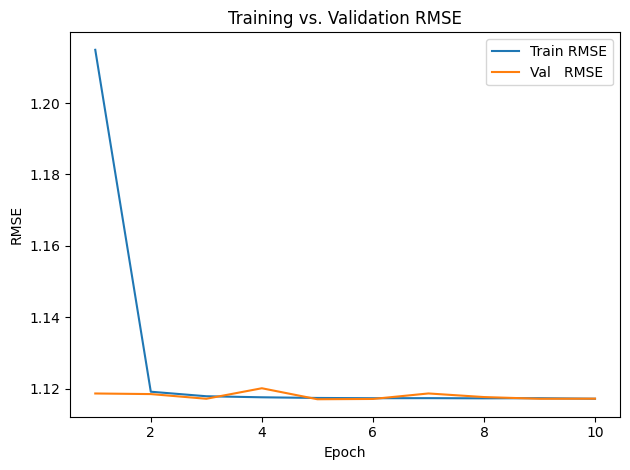

In [50]:
import matplotlib.pyplot as plt

# Assuming you have:
#   history = model.fit(...)

train_rmse = history.history["root_mean_squared_error"]
val_rmse = history.history["val_root_mean_squared_error"]
epochs = range(1, len(train_rmse) + 1)

plt.figure()
plt.plot(epochs, train_rmse, label="Train RMSE")
plt.plot(epochs, val_rmse, label="Val   RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training vs. Validation RMSE")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
model.save("../models/simple_mlp_model.keras")